# Import libraries

In [116]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load the dataset


In [117]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saravanansri/fruits-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/saravanansri/fruits-disease-dataset


# Set random seeds

In [118]:
SEED = 30

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Random seed set to : {SEED}')

Random seed set to : 30


# Set global hyperparameters.

In [119]:
DATASET_DIR = path
IMG_SIZE = (224, 224)
BATCH_SIZE = 10
EPOCHS = 25
LR = 1e-3 

# Load the training dataset 

In [120]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/Dataset/train/Mango',
    seed=SEED,
    image_size=IMG_SIZE,
    class_names=["Fresh", "Formalin-mixed"],
    batch_size=BATCH_SIZE,
    shuffle= True,
)

Found 965 files belonging to 2 classes.


# Load the test dataset

In [121]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
     f'{DATASET_DIR}/Dataset/train/Mango',
    seed=SEED,
    class_names=["Fresh", "Formalin-mixed"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 965 files belonging to 2 classes.


# Load the validation dataset

In [122]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
     f'{DATASET_DIR}/Dataset/valid/Mango',
    seed=SEED,
    class_names=["Fresh", "Formalin-mixed"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False
)

Found 208 files belonging to 2 classes.


# Get class names and number of classes

In [123]:
class_names = train_dataset.class_names
num_classes= len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Fresh', 'Formalin-mixed']


# Visualise dataset samples

In [124]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

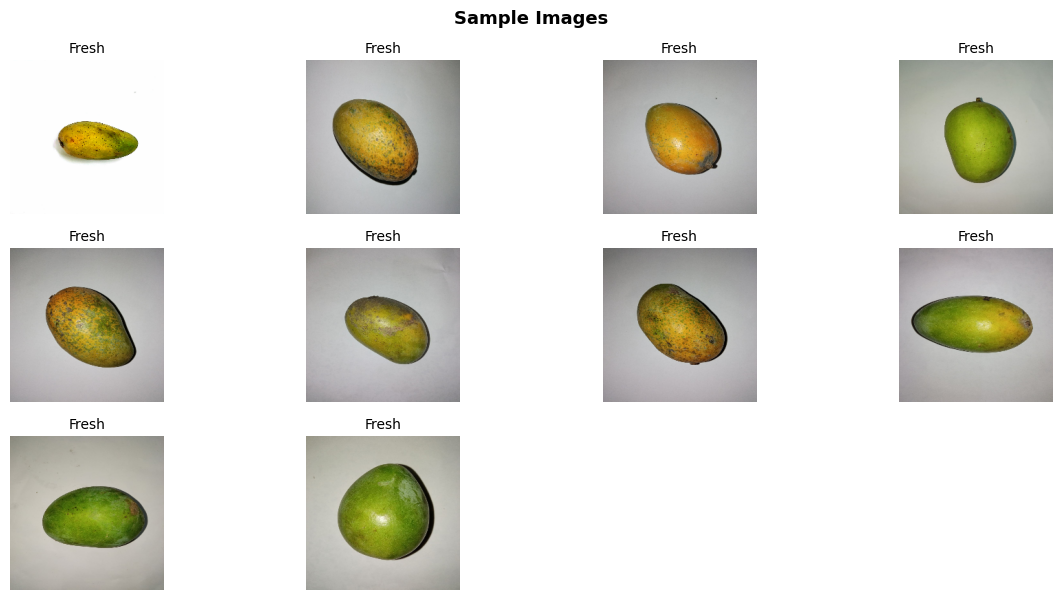

In [125]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[np.argmax(fixed_labels[i])], fontsize=10) 
    plt.axis('off')
plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample.png', dpi=120, bbox_inches='tight')
plt.show()

# Optimise the data pipeline.

In [126]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (train_dataset.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE))
valid_dataset = (valid_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))

 # Define the data augmentation pipeline.

In [127]:
# Augmentation for training only
data_augmentation = tf.keras.Sequential([
    # tf.keras.layers.RandomFlip("horizontal"),
    # tf.keras.layers.RandomRotation(0.2),
    # tf.keras.layers.RandomZoom(0.2),
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),       
    tf.keras.layers.RandomZoom(0.3),           
    tf.keras.layers.RandomContrast(0.2),       
    tf.keras.layers.RandomBrightness(0.2)
], name= 'data_augumentation')

# Visualise augmentation effects on one image

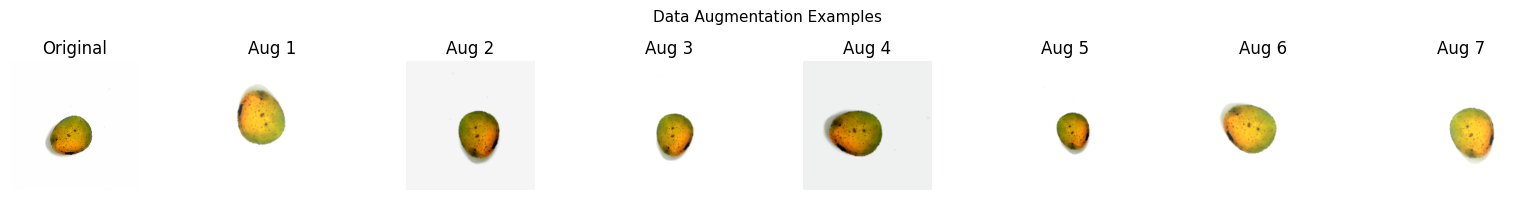

In [128]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] 
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample,training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.show()

# Define shared callbacks and utilities.

In [129]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [ tf.keras.callbacks.ModelCheckpoint(
        filepath=f'models/{name}_best.keras',
        monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
        ),
        ]
def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc= history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',results_dir='./'):

    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred,average="weighted"):.4f}')
    print(f'Recall: {recall_score(y_true, y_pred,average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='',xticklabels=class_names, yticklabels=class_names,
    annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


#  Build the Transfer Learning Model (MobileNetV3Small)

In [130]:
INPUT_SHAPE = (224, 224, 3)
OUTPUTS = num_classes

def build_transfer_model(input_shape, augmentation,backbone='mobilenetv3small'):
   
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name= 'mobilenetv3small_transfer'
    
    else:
    
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name= 'mobilenetv2_transfer'
    
    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model: {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
    
    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False)
    # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name=model_name), base_model
    
tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,backbone='mobilenetv3small')
tl_model.summary()

Base model: MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

# Compile Transfer learning model 

In [131]:

tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)



# Train the model.

In [132]:
tl_history = tl_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Epoch 1/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9047 - loss: 0.2340 - val_accuracy: 0.8173 - val_loss: 1.0412 - learning_rate: 0.0010
Epoch 2/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9886 - loss: 0.0579 - val_accuracy: 0.8606 - val_loss: 1.0243 - learning_rate: 0.0010
Epoch 3/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9969 - loss: 0.0232 - val_accuracy: 0.8365 - val_loss: 1.3022 - learning_rate: 0.0010
Epoch 4/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9938 - loss: 0.0205 - val_accuracy: 0.8558 - val_loss: 1.5824 - learning_rate: 0.0010
Epoch 5/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9969 - loss: 0.0148 - val_accuracy: 0.8558 - val_loss: 1.6599 - learning_rate: 0.0010
Epoch 6/25
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9951 - loss: 0.0158
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9948 - loss: 0.0155 - val_acc

# Evaluate the Transfer Learning Model on validation dataset

MobileNetV3 TL -> val_loss: 1.0243
MobileNetV3 TL -> val_accuracy: 0.8606


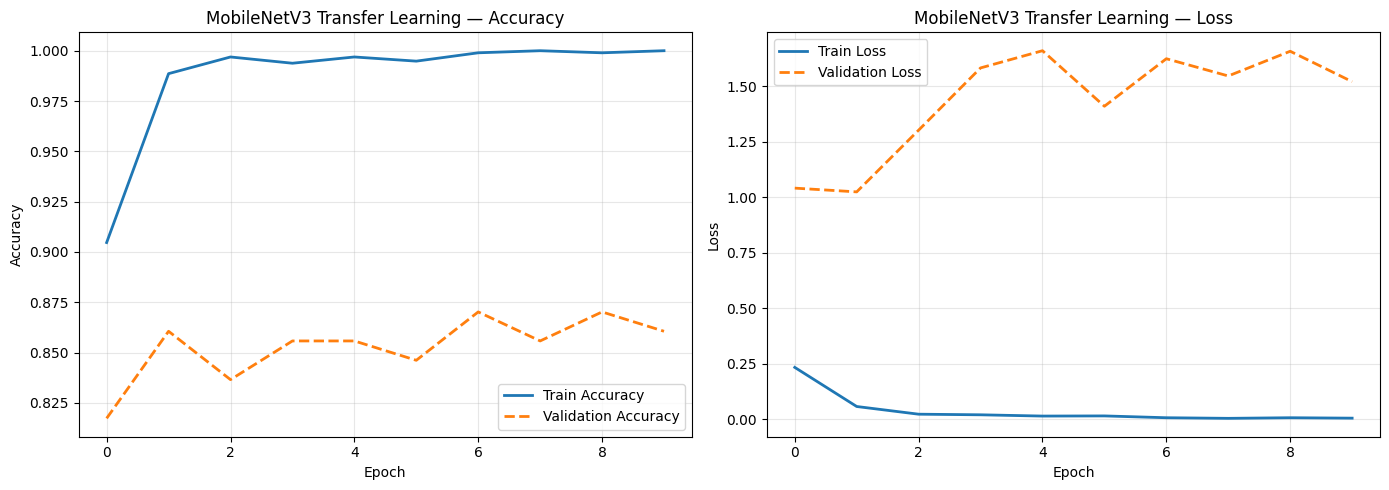

In [133]:
tl_val_loss, tl_val_acc = tl_model.evaluate(valid_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the Transfer Learning Model on test dataset

MobileNetV3 TL -> val_loss: 0.1452
MobileNetV3 TL -> val_accuracy: 0.9244


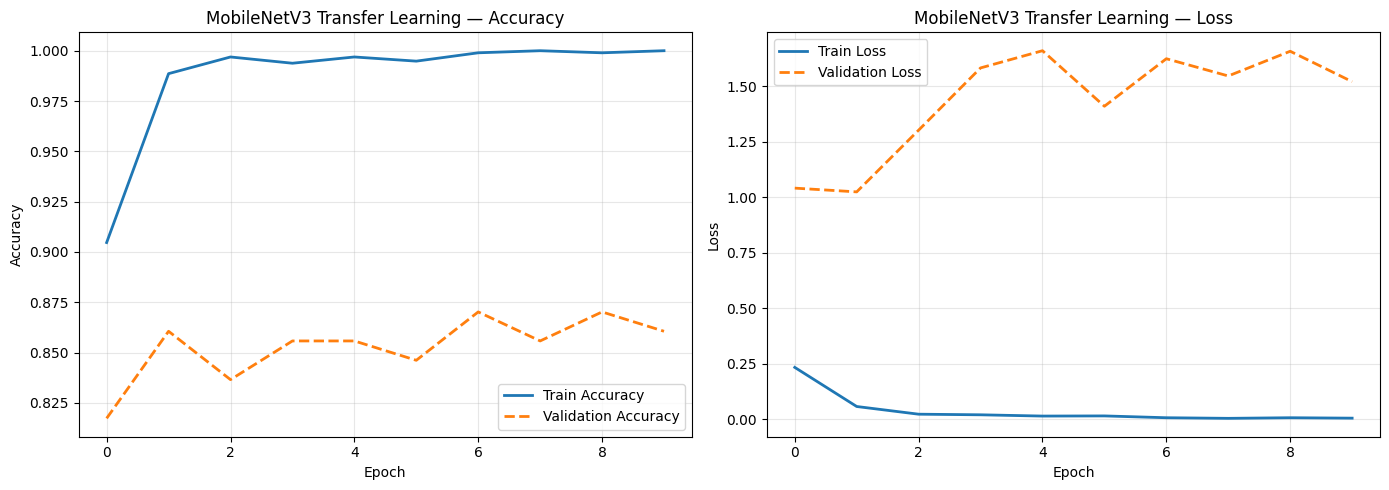

In [134]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_test_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_test_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate Model


Model
Accuracy : 0.9244
Precision : 0.9353
Recall: 0.9244
F1-Score : 0.9245

Classification Report:
                precision    recall  f1-score   support

         Fresh     1.0000    0.8633    0.9266       534
Formalin-mixed     0.8552    1.0000    0.9219       431

      accuracy                         0.9244       965
     macro avg     0.9276    0.9316    0.9243       965
  weighted avg     0.9353    0.9244    0.9245       965



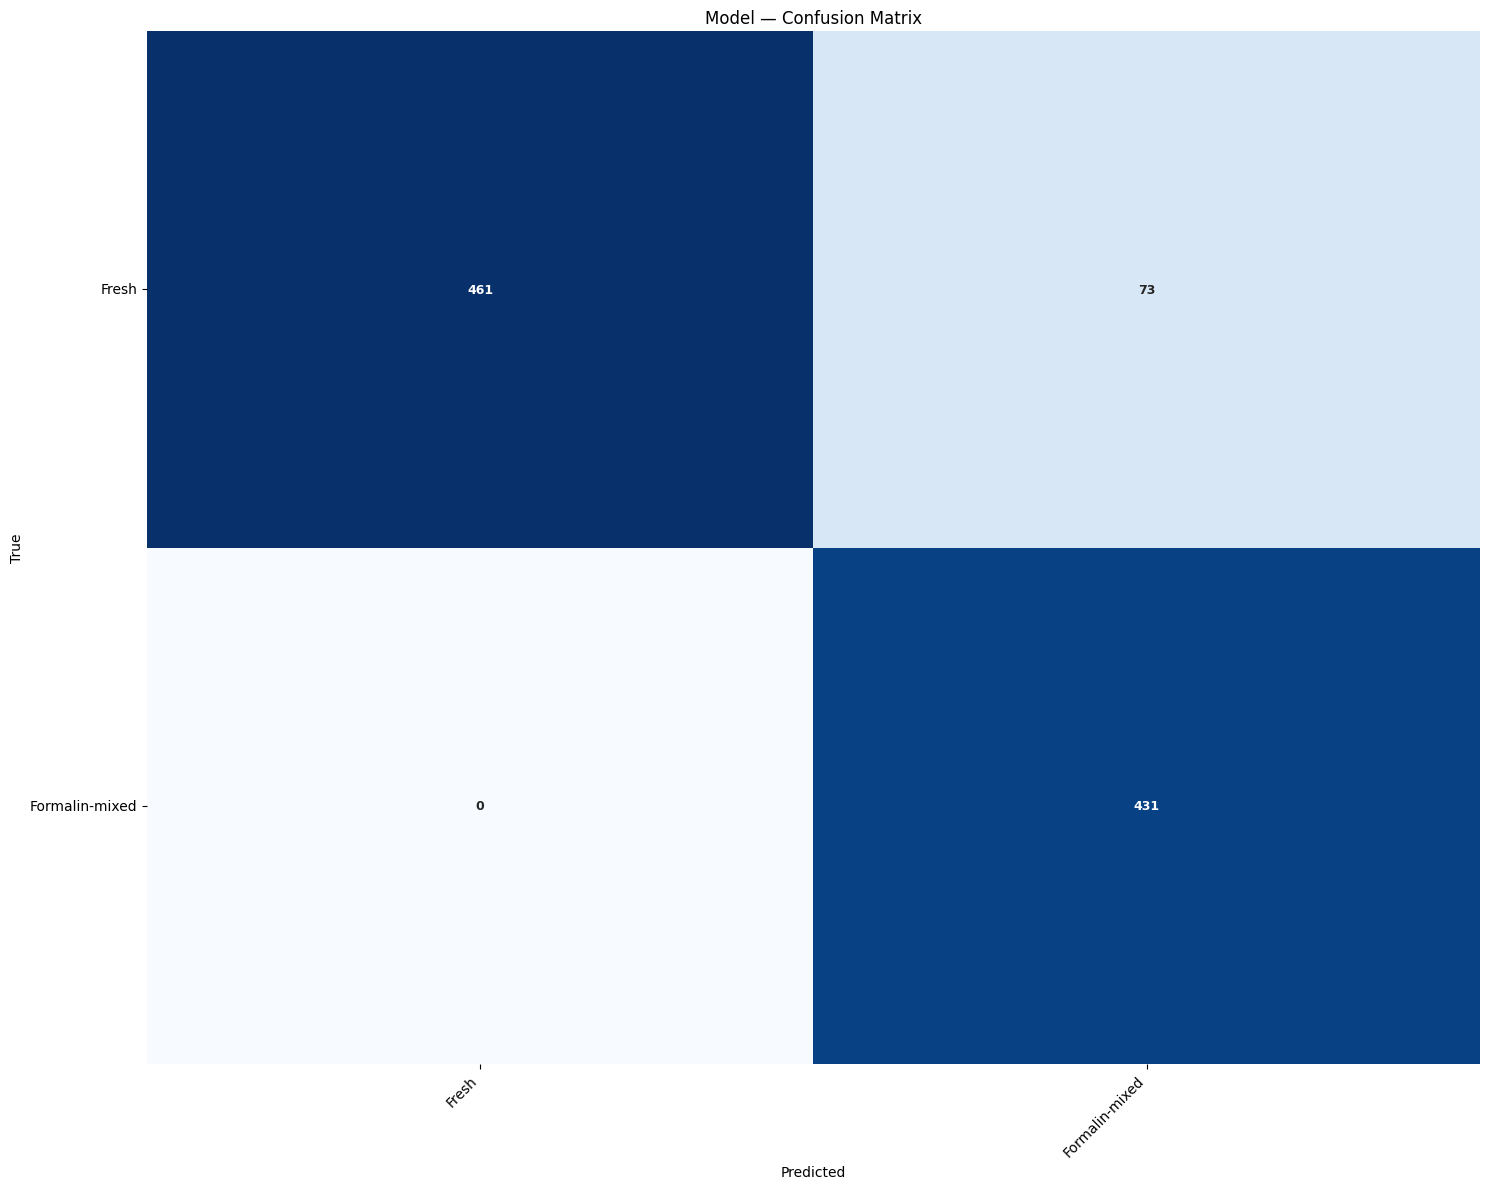

0.9243523316062177

In [135]:
evaluate_model(tl_model, test_dataset, class_names)

# Predict on a new image.

In [136]:
def predict_image(img_path, models_dict, class_names, image_size=IMG_SIZE):
    
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

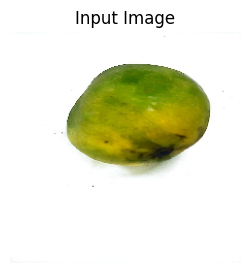


Predictions for: /kaggle/input/datasets/saravanansri/fruits-disease-dataset/Dataset/valid/Mango/Fresh/msg5170347760-63029.jpg
----------------------------------------
MobileNetV3 TL           : Formalin-mixed (p=0.9969)


In [137]:
image_path = '/kaggle/input/datasets/saravanansri/fruits-disease-dataset/Dataset/valid/Mango/Fresh/msg5170347760-63029.jpg'
predict_image(
    image_path,
    {'MobileNetV3 TL': tl_model},class_names
)

# Save Models 

In [138]:
os.makedirs('models', exist_ok=True)
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/mobilenetv3_transfer.keras
